# Sucrose Shock Analysis

Status: cleaned for the publication supplement. Supported cells start from the curated time-series data committed under `data/time-series/` and write generated files under `outputs/` directories.

Upstream image/video processing, raw acquisition data, segmentation outputs, bead-center detection outputs, and other large intermediates are intentionally not included in this repository. Cells from the original notebook that depended on those local upstream files have been replaced by archived notes.


### 📦 Importing Required Libraries

This cell imports all the necessary Python libraries for data analysis and plotting:

- `numpy`, `pandas` for data handling  
- `matplotlib.pyplot`, `seaborn` for plotting and visualization  
- `os`, `pathlib.Path` for file handling  
- `scipy` libraries for signal processing and curve fitting  
- `sklearn.metrics.r2_score` for computing the R² value  
- `%matplotlib inline` ensures that plots display directly in the notebook


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import scipy
from scipy.optimize import curve_fit
import scipy.signal
import re
from scipy.interpolate import interp1d
import scipy.signal as signal
from sklearn.metrics import r2_score

import sys
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "bead_time_series.py").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
else:
    sys.path.insert(0, str((NOTEBOOK_DIR / "code" / "bead-assay").resolve()))
from bead_time_series import ROOT, legacy_speed_tree, legacy_condition_folder, read_legacy_speed_csv, iter_condition_traces, median_kernel_size

# Ensure plots are rendered in the notebook
%matplotlib inline

## Defining terms for the exponential function 


In [2]:
dict_for_plotting = {}
for name in ['0', '100', '200', '300', '400', '500']:
    dict_for_plotting[name] = []

In [3]:
# Define exponential functions
def old_exp_decrease(t, A, tau, C, t0):
    return A / (1 + np.exp((t-175-t0) / tau)) + C

def exp_decrease(t, tau, t0):
    global speed_initial
    global speed_final
    return (speed_initial-speed_final) / (1 + np.exp((t-175-t0) / tau)) + speed_final

def exp_increase(t, tau, t0):
    global speed_increase_max
    global speed_increase_min
    return speed_increase_min + (speed_increase_max  - speed_increase_min)/ (1 + np.exp(-(t-270-t0) / tau))

def old_exp_increase(t, B, tau, D, t0):
    return B * (1 - np.exp(-(t - t0) / tau)) + D

def exponential_decay(t, tau, t0):
    global speed_initial
    global speed_final
    return np.where(t < t0, speed_initial, (speed_initial-speed_final) * np.exp(-(t - t0) / tau) + speed_final)

def calculate_time_constants(time, speed, filename, sucrose_choice):
    results = []

    #normalize speed for ease of fitting
    speed = speed / np.average(speed[time<=180]) #normally 300

    # Filter data for decrease and increase
    mask_decrease = (time >= 175) & (time <= 240)
    time_decrease = time[mask_decrease]
    speed_decrease = speed[mask_decrease]

    mask_increase = (time > 250) & (time <= 360)
    time_increase = time[mask_increase]
    speed_increase = speed[mask_increase]
   
    global speed_initial
    global speed_final
    speed_initial = np.average(speed[(time >= 155) & (time <= 175)])
    speed_final = np.average(speed[(time >= 215) & (time <= 235)])

    global speed_increase_max
    global speed_increase_min
    speed_increase_min = np.average(speed[(time >= 240) & (time <= 260)])
    speed_increase_max = np.average(speed[(time >= 330) & (time <= 350)])


    global dict_for_plotting
    dict_for_plotting[filename].append(speed[(time >= 155) & (time <= 175)])
    dict_for_plotting['0'].append(speed[(time >= 215) & (time <= 235)])

    #Fit the decrease segment
    try:
        popt_decrease, _ = curve_fit(
            exp_decrease,
            time_decrease,
            speed_decrease,
            p0=[10, 10],
            bounds=(0, np.inf)
        )
        A_dec, C_dec = speed_initial-speed_final, speed_final
        tau_dec, t0_dec = popt_decrease
    except Exception as e:
        print(f"Error fitting decrease for {filename}: {e}")
        tau_dec = np.nan
        A_dec, tau_dec, C_dec, t0_dec = [np.nan, np.nan, np.nan, np.nan]
        popt_decrease = [np.nan, np.nan, np.nan, np.nan]

    if True: #plotting to double check
        if filename == "500": #filename[-13:-10]
            #print('here')
            plt.plot(time, speed)
            plt.plot(time_decrease, exp_decrease(time_decrease, *popt_decrease))


    # Fit the increase segment
    try:
        popt_increase, _ = curve_fit(
            exp_increase, time_increase, speed_increase, p0=[3, -10]
        )
        tau_inc, t0_inc = popt_increase
    except Exception as e:
        print(f"Error fitting increase for {filename}: {e}")
        tau_inc = np.nan
        popt_increase = [np.nan, np.nan]

    if True:
        if filename == "500":
            plt.plot(time_increase, exp_increase(time_increase, *popt_increase))

    # Save results for this concentration
    condition = filename.split(".csv")[
        0
    ]  # Assuming the filename contains the concentration info
    results.append(
        {
            "Condition": condition,
            "Tau (Decrease)": tau_dec,
            "Tau (Increase)": tau_inc,
            "Time Range (Decrease)": f"180-270",
            "Time Range (Increase)": f"270-{time[-1]}",
        }
    )

    return tau_dec, t0_dec, A_dec, tau_inc

### Data Processing Functions

This section defines three functions used to process time-series data by interpolating to a fixed frame rate and binning into defined intervals:


In [4]:
def convert_to_300fps(time_stamps, data, target_fps=300):# Calculate the total duration
    total_time = time_stamps[-1]
    
    # Generate new time stamps at the target FPS
    new_time_stamps = np.linspace(0, total_time, int(total_time * target_fps))
    
    # Create a linear interpolator
    interpolator = interp1d(time_stamps, data, kind='linear', fill_value='extrapolate')
    
    # Interpolate data to the new time stamps
    interpolated_data = interpolator(new_time_stamps)
    
    return new_time_stamps[:380*target_fps], interpolated_data[:380*target_fps]

def bin_data(time_stamps, data, bin_size=0.1):
    data = data[time_stamps < 380]
    time_stamps = time_stamps[time_stamps < 380]
    
    # Determine the range of time stamps
    start_time = 0
    end_time = 380
    
    # Create bin edges
    bin_edges = np.arange(start_time, end_time + bin_size, bin_size)
    
    # Calculate bin indices for each time stamp
    bin_indices = np.digitize(time_stamps, bin_edges, right=False) - 1  # Bin indices (0-based)

    # Initialize lists to store results
    binned_times = np.arange(0,end_time,0.1)
    averaged_data = np.zeros_like(binned_times)
    
    # Iterate over each bin
    for i in range(len(bin_edges) - 1):
        # Get indices of data points in the current bin
        indices_in_bin = np.where(bin_indices == i)[0]
        
        if len(indices_in_bin) > 0:
            # Calculate the midpoint of the current bin
            bin_midpoint = (bin_edges[i] + bin_edges[i + 1]) / 2
            binned_times[i] = (bin_midpoint)
            
            # Calculate the average of data points in the current bin
            average_value = np.mean(data[indices_in_bin])
            averaged_data[i] = (average_value)
    
    return np.array(binned_times), np.array(averaged_data)

def bin_data_2(time_stamps, data, bin_size=0.1):
    T = time_stamps[time_stamps<=380]
    F = data[time_stamps<=380]
    
    # Resample into 4000 bins
    data_F = np.zeros(3800)
    data_T = np.zeros(3800)

    bin = 0
    counter = 0

    for kk in range(len(T)):
        counter += 1
        pos = int(T[kk] // 0.1)
        if pos < 3800:
            data_F[pos] += F[kk]
            if T[kk] // 0.1 > bin + 1:
                data_F[pos - 1] /= counter
                data_T[pos - 1] = (bin + 0.5) * 0.1
                counter = 0
                bin += 1
        else:
            data_F[pos - 1] /= counter
            data_T[pos - 1] = (bin + 0.5) * 0.1
            break
    
    return data_T, data_F

## Sucrose 
Extracing motor speeds from the sucrose results folder 


<ipython-input-1-2c392d7d7f7b>:13: RuntimeWarning: overflow encountered in exp
  return speed_increase_min + (speed_increase_max  - speed_increase_min)/ (1 + np.exp(-(t-270-t0) / tau))


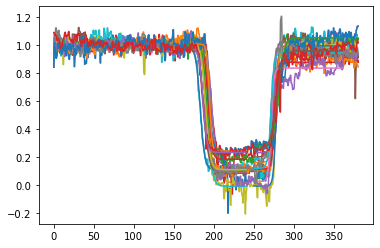

In [5]:
parentDir = legacy_speed_tree(assay="Sucrose")
outputDir = ROOT / "outputs" / "bead" / "sucrose-shock"
os.makedirs(outputDir, exist_ok=True)

sucrose_choice = True
time_mult = 10

# Initialize the list to store time, data, and sucrose concentrations
all_time = []
all_data = []
concentrations = []

tau_values = {}
t0_values = {}
A_values = {}
tau_inc_values = {}

for concentration in [200, 300, 400, 500]:
    condition_dir = Path(parentDir) / f"{concentration}mM"
    csv_files = sorted(condition_dir.glob("*.csv"))
    if not csv_files:
        print(f"No traces found for {concentration} mM in {condition_dir}")
        continue

    tau_values[str(concentration)] = []
    t0_values[str(concentration)] = []
    A_values[str(concentration)] = []
    tau_inc_values[str(concentration)] = []
    condition_cells = []

    for file_path in csv_files:
        if concentration == 200 and "cell4" in file_path.stem:
            continue

        trace = read_legacy_speed_csv(file_path)
        time = trace["frame"].to_numpy() / 300
        data = trace["frequency_hz"].to_numpy()
        if len(data) == 0:
            continue
        if data[0] < 0:
            data = data * -1

        data = signal.medfilt(data, kernel_size=median_kernel_size(time, window_s=1.0))
        new_time, interp_data = bin_data(time, data)

        tau_dec, t0_dec, A_dec, tau_inc = calculate_time_constants(new_time, interp_data, str(concentration), sucrose_choice)
        if ((tau_dec > 0) & (tau_dec < 40)):
            tau_values[str(concentration)] += [float(tau_dec)]
            t0_values[str(concentration)] += [float(t0_dec)]
            A_values[str(concentration)] += [float(A_dec)]
            tau_inc_values[str(concentration)] += [float(tau_inc)]

        condition_cells.append(interp_data)

    if not condition_cells:
        continue

    allcells = np.asarray(condition_cells)
    data_mean = np.average(allcells, axis=0)
    data_mean_norm = data_mean / np.average(data_mean[:180 * time_mult])
    data_std = np.std(allcells, axis=0) / np.average(data_mean[:180 * time_mult])
    upper = data_mean_norm + 0.5 * data_std
    lower = data_mean_norm - 0.5 * data_std

    time = new_time
    all_time.append(time)
    all_data.append(data_mean_norm)
    concentrations.append(float(concentration))

    df_output = pd.DataFrame({
        'Time': time,
        'Normalized Data': data_mean_norm
    })
    output_file = outputDir / f"normalized_data_{concentration}mM.csv"
    # df_output.to_csv(output_file, index=False)

# Sort the concentrations and associated data
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]

In [6]:
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]

print("Sorted concentrations:", sorted_concentrations)

# Save a code-generated panel corresponding to the sucrose motor-speed panel.
figure_dir = ROOT / "outputs" / "figure-panels"
figure_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'font.size': 25, 'font.family': 'Arial'})
fig, ax = plt.subplots(figsize=(10, 5.5))
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)
ax.tick_params(axis='x', direction='in', width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', width=2, length=7.5, pad=8)

for time_arr, mean_arr, conc in zip(sorted_times, sorted_data, sorted_concentrations):
    ax.plot(time_arr, mean_arr, label=f'{int(conc)} mM')

ax.axvspan(180, 270, color='lightgray', alpha=0.6)
ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Normalized)', fontsize=25)
ax.set_xlim(0, 380)
ax.set_ylim(0, 1.25)
ax.set_xticks(np.arange(0, 381, 50))
ticks = np.arange(0, 1.26, 0.25)
ax.set_yticks(ticks[:-1])
ax.legend(loc='lower left', fontsize=25, frameon=False)
fig.tight_layout()
fig.savefig(figure_dir / "figure-1d-sucrose-motor-speed.pdf", dpi=350, bbox_inches='tight')
plt.close(fig)


Sorted concentrations: [200.0, 300.0, 400.0, 500.0]


In [7]:
def equalize_lists(data):
    if not data:
        return {}

    lengths = [len(v) for v in data.values()]
    if max(lengths) == 0:
        return {k: [] for k in data}

    max_length = max(lengths)
    return {
        k: v + [np.nan] * (max_length - len(v))
        for k, v in data.items()
    }

### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.


### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.


### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.


### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Global plot settings
# -------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 25})

# -------------------------------
# Paths
# -------------------------------
save_root = ROOT / "outputs" / "bead" / "sucrose-individual-cells"
os.makedirs(save_root, exist_ok=True)

# -------------------------------
# Loop through compact canonical traces
# -------------------------------
for row, trace in iter_condition_traces(assay="Sucrose"):
    fig, ax = plt.subplots(figsize=(20, 10))

    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(10)

    ax.tick_params(axis='x', direction='in', labelsize=150, width=10, length=50, pad=8)
    ax.tick_params(axis='y', direction='in', labelsize=150, width=10, length=50, pad=8)

    ax.plot(trace["time_s"], trace["frequency_hz"], linewidth=6, color="blue")

    ax.set_xticks(np.arange(0, 381, 150))
    ax.set_xlim(0, 380)
    ax.set_yticks(np.arange(0, 90, 40))
    ax.set_ylim(0, 80)
    ax.axvspan(180, 270, color="lightgray", alpha=0.6)

    save_path = save_root / f"{row['condition_mM']}mM_{row['cell_id']}.pdf"
    plt.savefig(save_path, dpi=350)
    plt.close(fig)
    print(f"Saved figure: {save_path}")

Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell1.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell2.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell3.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell4.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell5.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell6.pdf
Saved figure: C:\Users\wadhw\ASU Dropbox\Navish Wadhwa\ASU\Projects\2026-Meneses-Osmotic\outputs\bead\sucrose-individual-cells\200mM_cell7.pdf

### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.


### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.


### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.


### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.


### Archived upstream-dependent cell

This original code cell depended on local upstream files or intermediate products that are intentionally not included in this time-series-first supplement. You do not need to run it to understand or reproduce the maintained results. The supported workflow starts from data/time-series/ and writes regenerated products under outputs/.
